# 1. Identificação da abordagem

# 2. Preparação e execução

In [8]:
# Bibliotecas padrão de manipulação de sistema e caminhos
import os
import copy
import time

# Bibliotecas fundamentais de Machine Learning e Tensores
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Bibliotecas de Visão Computacional do PyTorch
from torchvision import datasets, models, transforms

# Bibliotecas para métricas e visualização
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Configurando o dispositivo (Usa GPU se disponível, senão CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda:0


In [9]:
# Defina o caminho para a pasta onde você salvou o dataset
data_dir = '.' # Mude isso se o seu caminho for diferente
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

# Vamos checar se as pastas existem para garantir que a estrutura está correta
print("Diretório de treino existe?", os.path.exists(train_dir))
print("Diretório de teste existe?", os.path.exists(test_dir))

Diretório de treino existe? True
Diretório de teste existe? True


In [10]:
# Definindo as transformações mínimas para a Baseline
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)), # Redimensiona todas as imagens para 224x224
        transforms.ToTensor(),         # Converte para Tensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalização padrão da ResNet
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [11]:
# Mapeando as imagens das pastas aplicando as transformações
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

# Criando os geradores de lotes (DataLoaders)
# O batch_size define quantas imagens passam pela rede antes de atualizar os pesos
batch_size = 32

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True, num_workers=0),
    'test': DataLoader(image_datasets['test'], batch_size=batch_size, shuffle=False, num_workers=0)
}

# Guardando o tamanho do dataset e os nomes das classes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

print(f"Tamanho do dataset de treino: {dataset_sizes['train']} imagens")
print(f"Tamanho do dataset de teste: {dataset_sizes['test']} imagens")
print(f"Classes encontradas pelo PyTorch: {class_names}")

Tamanho do dataset de treino: 900 imagens
Tamanho do dataset de teste: 300 imagens
Classes encontradas pelo PyTorch: ['asphalt', 'belgian_blocks', 'offroad']


In [12]:
# 1. Carregar a ResNet18 pré-treinada
modelo = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Modificar a última camada (Fully Connected - fc)
# Pegamos o número de características que entram na última camada
num_ftrs = modelo.fc.in_features

# Substituímos a última camada por uma nova com saída igual ao número de nossas classes (3)
modelo.fc = nn.Linear(num_ftrs, len(class_names))

# 3. Enviar o modelo para o dispositivo correto (CPU ou GPU)
modelo = modelo.to(device)

# 4. Definir a Função de Perda (Loss)
# CrossEntropyLoss é o padrão para classificação multiclasse. 
# Como estamos na Baseline, NÃO vamos tratar o desbalanceamento das classes ainda.
criterio = nn.CrossEntropyLoss()

# 5. Definir o Otimizador
# O Adam é um otimizador robusto e rápido. Taxa de aprendizado (lr) de 0.001 é um bom começo.
otimizador = optim.Adam(modelo.parameters(), lr=0.001)

print("Modelo carregado e configurado com sucesso!")

Modelo carregado e configurado com sucesso!


In [13]:
def treinar_modelo(modelo, criterio, otimizador, num_epochs=5):
    desde = time.time()
    
    # Vamos guardar os melhores pesos do modelo para usarmos no final
    melhor_modelo_wts = copy.deepcopy(modelo.state_dict())
    melhor_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Época {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Cada época tem uma fase de treino e de teste
        for fase in ['train', 'test']:
            if fase == 'train':
                modelo.train()  # Configura o modelo para modo de treinamento
            else:
                modelo.eval()   # Configura o modelo para modo de avaliação

            running_loss = 0.0
            running_corrects = 0

            # Iterando sobre os dados em lotes (batches)
            for inputs, labels in dataloaders[fase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zera os gradientes do otimizador para não acumular da iteração anterior
                otimizador.zero_grad()

                # Forward (Passagem para frente)
                # Só rastreia o histórico se for fase de treino
                with torch.set_grad_enabled(fase == 'train'):
                    outputs = modelo(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterio(outputs, labels)

                    # Backward e otimização apenas no treino
                    if fase == 'train':
                        loss.backward()
                        otimizador.step()

                # Estatísticas
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calcula a perda e acurácia médias da época
            epoch_loss = running_loss / dataset_sizes[fase]
            epoch_acc = running_corrects.double() / dataset_sizes[fase]

            print(f'{fase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Copia o modelo se for a melhor acurácia no teste
            if fase == 'test' and epoch_acc > melhor_acc:
                melhor_acc = epoch_acc
                melhor_modelo_wts = copy.deepcopy(modelo.state_dict())

        print()

    tempo_decorrido = time.time() - desde
    print(f'Treinamento concluído em {tempo_decorrido // 60:.0f}m {tempo_decorrido % 60:.0f}s')
    print(f'Melhor Acurácia de Teste: {melhor_acc:.4f}')

    # Carrega os melhores pesos do modelo
    modelo.load_state_dict(melhor_modelo_wts)
    return modelo

# Iniciando o treinamento da Baseline
# Como é a baseline e estamos na CPU, 5 épocas são suficientes para ver o modelo aprender
print("Iniciando o treinamento...")
modelo_treinado = treinar_modelo(modelo, criterio, otimizador, num_epochs=5)

Iniciando o treinamento...
Época 1/5
----------
Train Loss: 0.3614 Acc: 0.8644
Test Loss: 1.4540 Acc: 0.8133

Época 2/5
----------
Train Loss: 0.1161 Acc: 0.9633
Test Loss: 1.0379 Acc: 0.8233

Época 3/5
----------
Train Loss: 0.1933 Acc: 0.9478
Test Loss: 0.4757 Acc: 0.8700

Época 4/5
----------
Train Loss: 0.0536 Acc: 0.9833
Test Loss: 0.5053 Acc: 0.8633

Época 5/5
----------
Train Loss: 0.0595 Acc: 0.9833
Test Loss: 0.4910 Acc: 0.8500

Treinamento concluído em 1m 55s
Melhor Acurácia de Teste: 0.8700


# 3. Experimentos

A hipótese ou motivação: A baseline demonstrou um viés severo em direção à classe majoritária (Asphalt, com 94% de recall), falhando gravemente em identificar a classe minoritária (Belgian Blocks, com apenas 25% de recall) devido ao desbalanceamento dos dados.

O que será modificado: Iremos alterar a função de erro (CrossEntropyLoss). Adicionaremos "pesos" matemáticos a ela. Assim, quando o modelo errar uma foto de Belgian Blocks, ele será penalizado com muito mais força do que quando errar uma foto de Asphalt. Isso forçará a rede a prestar atenção na classe minoritária.

# 4. Resultados

Gerando previsões para o conjunto de teste...

--- Relatório de Classificação ---
                precision    recall  f1-score   support

       asphalt       0.94      0.94      0.94       218
belgian_blocks       0.89      0.25      0.39        32
       offroad       0.67      0.96      0.79        50

      accuracy                           0.87       300
     macro avg       0.83      0.72      0.71       300
  weighted avg       0.89      0.87      0.85       300



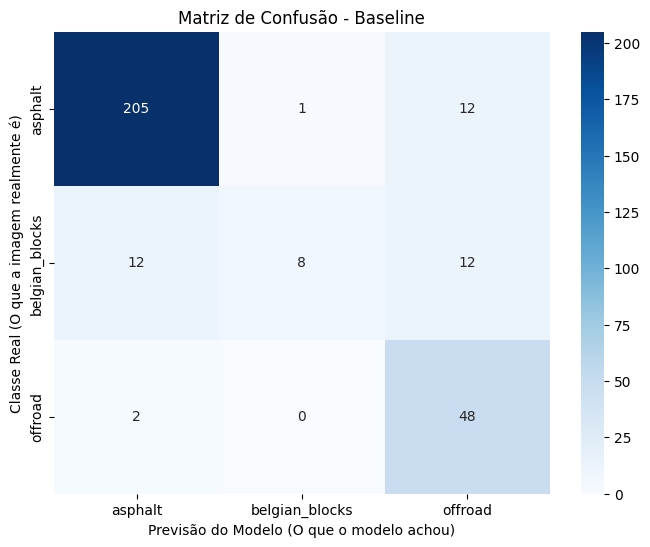

In [14]:
# Colocamos o modelo em modo de avaliação (não aprende mais, só prevê)
modelo_treinado.eval()

y_true = [] # Lista para guardar a classe real
y_pred = [] # Lista para guardar a previsão do modelo

print("Gerando previsões para o conjunto de teste...")

# Desabilitamos o cálculo de gradientes pois não estamos treinando (economiza memória)
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # O modelo dá as probabilidades
        outputs = modelo_treinado(inputs)
        
        # Pegamos a classe com maior probabilidade
        _, preds = torch.max(outputs, 1)
        
        # Movemos os resultados de volta para a CPU para usar no Scikit-Learn
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 1. Relatório de Classificação (Precisão, Recall, F1-Score)
print("\n--- Relatório de Classificação ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Plotando a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão do Modelo (O que o modelo achou)')
plt.ylabel('Classe Real (O que a imagem realmente é)')
plt.title('Matriz de Confusão - Baseline')
plt.show()

# 5. Análise Crítica

# 6. Uso de ferramentas